<a href="https://colab.research.google.com/github/Robert-DA-78/Python/blob/main/Credit_Scoring_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Initial shape: (1319, 12)

First few rows:
  card  reports       age  income     share  expenditure owner selfemp  \
0  yes        0  37.66667  4.5200  0.033270   124.983300   yes      no   
1  yes        0  33.25000  2.4200  0.005217     9.854167    no      no   
2  yes        0  33.66667  4.5000  0.004156    15.000000   yes      no   
3  yes        0  30.50000  2.5400  0.065214   137.869200    no      no   
4  yes        0  32.16667  9.7867  0.067051   546.503300   yes      no   

   dependents  months  majorcards  active  
0           3      54           1      12  
1           3      34           1      13  
2           4      58           1       5  
3           0      25           1       7  
4           2      64           1       5  

Missing values:
card           0
reports        0
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        0
dependents     0
months         0
majorcards     0
active         0
d

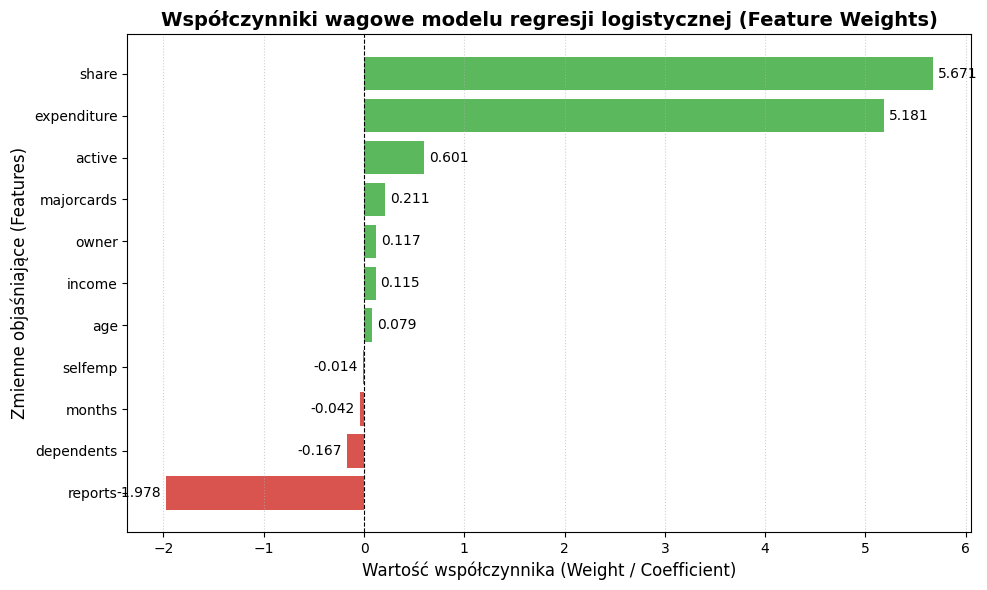

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from google.colab import drive

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Python-Mate/credit_card_data.csv')

print("Initial shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# 2. Check for missing values and remove
print("\nMissing values:")
print(df.isnull().sum())
df = df.dropna()

# 3. Convert text fields (card, owner, selfempl) to numeric: yes -> 1, no -> 0
text_cols = ['card', 'owner', 'selfempl']
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print("\nData after mapping text columns:")
print(df.head())

# 4. Prepare data for model building
X = df.drop('card', axis=1)
y = df['card']

# 5. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Accuracy check
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)
print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# 8. Extract feature coefficients
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values()
print("\nModel Coefficients (Weights):")
print(coefficients)

# Build two-color bar chart
plt.figure(figsize=(10, 6))
colors = ['#d9534f' if val < 0 else '#5cb85c' for val in coefficients.values]
bars = plt.barh(coefficients.index, coefficients.values, color=colors)

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Współczynniki wagowe modelu regresji logistycznej (Feature Weights)', fontsize=14, fontweight='bold')
plt.xlabel('Wartość współczynnika (Weight / Coefficient)', fontsize=12)
plt.ylabel('Zmienne objaśniające (Features)', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Add values next to bars
for bar in bars:
    width = bar.get_width()
    ha = 'left' if width >= 0 else 'right'
    offset = 0.05 if width >= 0 else -0.05
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', ha=ha, fontsize=10)

plt.tight_layout()
plt.savefig('logistic_regression_weights.png', dpi=300)
plt.show()


Accuracy na zbiorze testowym: 0.9621
Rozkład klas w zmiennej docelowej 'card':
card
1    0.775588
0    0.224412
Name: proportion, dtype: float64


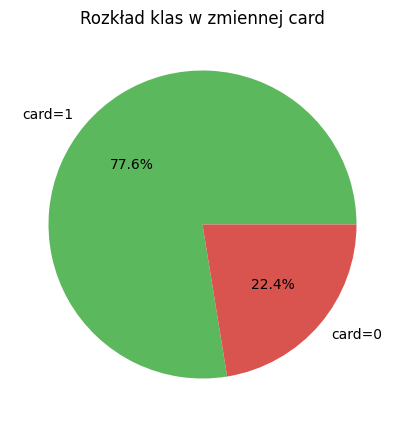

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy na zbiorze testowym: {acc:.4f}")

class_ratio = df['card'].value_counts(normalize=True)
print("Rozkład klas w zmiennej docelowej 'card':")
print(class_ratio)

plt.figure(figsize=(5,5))
plt.pie(class_ratio.values, labels=[f"card={i}" for i in class_ratio.index],
        autopct='%1.1f%%', colors=['#5cb85c', '#d9534f'])
plt.title('Rozkład klas w zmiennej card')
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
specificity = tn / (tn + fp)

print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-score:    {f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"\nMacierz pomyłek:\nTN={tn}  FP={fp}\nFN={fn}  TP={tp}")
print("\n", classification_report(y_test, y_pred))


Precision:   0.9752
Recall:      0.9752
F1-score:    0.9752
Specificity: 0.9194

Macierz pomyłek:
TN=57  FP=5
FN=5  TP=197

               precision    recall  f1-score   support

           0       0.92      0.92      0.92        62
           1       0.98      0.98      0.98       202

    accuracy                           0.96       264
   macro avg       0.95      0.95      0.95       264
weighted avg       0.96      0.96      0.96       264



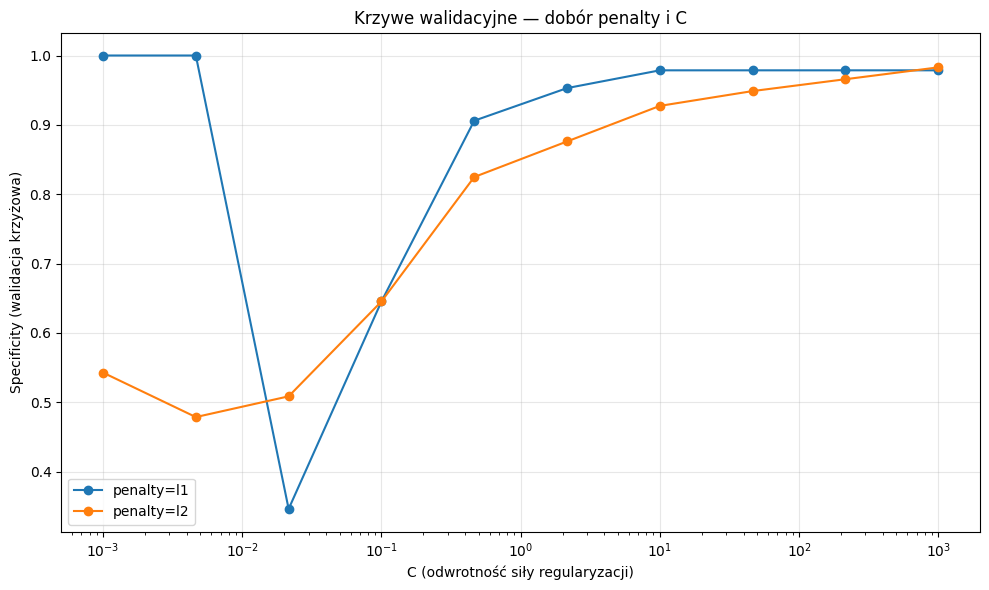

Najlepsze hiperparametry: {'C': np.float64(0.001), 'penalty': 'l1'}
Najlepszy wynik (CV): 1.0


In [ ]:
from sklearn.model_selection import validation_curve, GridSearchCV
from sklearn.metrics import make_scorer, confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

spec_scorer = make_scorer(specificity_score)

C_values = np.logspace(-3, 3, 10)   # 10 zamiast 20
penalties = ['l1', 'l2']

plt.figure(figsize=(10, 6))
for penalty in penalties:
    train_scores, test_scores = validation_curve(
        LogisticRegression(penalty=penalty, solver='liblinear', random_state=42, max_iter=1000),
        X_train_scaled, y_train,
        param_name='C', param_range=C_values,
        scoring=spec_scorer, cv=3, n_jobs=-1
    )
    plt.plot(C_values, test_scores.mean(axis=1), marker='o', label=f'penalty={penalty}')

plt.xscale('log')
plt.xlabel('C (odwrotność siły regularyzacji)')
plt.ylabel('Specificity (walidacja krzyżowa)')
plt.title('Krzywe walidacyjne — dobór penalty i C')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('validation_curves.png', dpi=300)
plt.show()


param_grid = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-3, 3, 10)
}

grid = GridSearchCV(
    LogisticRegression(solver='liblinear', random_state=42, max_iter=1000),
    param_grid=param_grid,
    scoring=spec_scorer,
    cv=3,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Najlepsze hiperparametry:", grid.best_params_)
print("Najlepszy wynik (CV):", grid.best_score_)

best_model = grid.best_estimator_

In [ ]:
y_pred_best = best_model.predict(X_test_scaled)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

acc_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
specificity_best = tn / (tn + fp)

print("=== Model bazowy vs zoptymalizowany ===")
print(f"{'Metryka':<12}{'Bazowy':>10}{'Zoptymalizowany':>18}")
print(f"{'Accuracy':<12}{acc:>10.4f}{acc_best:>18.4f}")
print(f"{'Precision':<12}{precision:>10.4f}{precision_best:>18.4f}")
print(f"{'Recall':<12}{recall:>10.4f}{recall_best:>18.4f}")
print(f"{'F1-score':<12}{f1:>10.4f}{f1_best:>18.4f}")
print(f"{'Specificity':<12}{specificity:>10.4f}{specificity_best:>18.4f}")

=== Model bazowy vs zoptymalizowany ===
Metryka         Bazowy   Zoptymalizowany
Accuracy        0.9621            0.2348
Precision       0.9752            0.0000
Recall          0.9752            0.0000
F1-score        0.9752            0.0000
Specificity     0.9194            1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Wnioski**

Model regresji logistycznej do oceny zdolności kredytowej osiągnął wysoką skuteczność (accuracy = 96,2%, F1 = 0,975), jednak ze względu na niezbalansowany rozkład klas (77,6% vs 22,4%) sama accuracy nie jest wiarygodną miarą jakości. Kluczowa okazała się **specificity** (0,919), najważniejsza z perspektywy biznesowej, ponieważ minimalizuje ryzyko błędnego przyznania karty klientowi, który nie powinien jej otrzymać.

Próba optymalizacji hiperparametrów wyłącznie pod kątem specificity ujawniła istotne ryzyko metodologiczne: model uzyskał pozornie idealny wynik (specificity = 1,0), lecz stało się to kosztem całkowitej utraty zdolności predykcyjnej (recall = 0, accuracy = 0,235). Model zaczął przewidywać wyłącznie jedną klasę. Pokazuje to, że **optymalizacja pojedynczej metryki w izolacji może prowadzić do modeli zdegenerowanych**, dlatego strojenie należy prowadzić w oparciu o metrykę zbalansowaną (np. `balanced_accuracy`) lub z ograniczeniem zakresu regularyzacji, zachowując jednocześnie kontrolę nad wszystkimi kluczowymi wskaźnikami (precision, recall, F1, specificity), a nie tylko jednym z nich.